# **Informe de EDA sobre los jugadores de la FIFA**

En este informe de EDA lo que vamos a analizar son diferentes características sobre el dataset limpio de `players_clean.csv`.

## 1. Carga de librerías y datos

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Para mejorar la estética vamos a utilizar los siguientes comandos.

In [12]:
# Configuración visual moderna
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Y cargamos los datos de players.csv que previamente hemos realizado una limpieza.

In [13]:
# Cargar datos
df = pd.read_csv("../data/clean/players_clean.csv")

Y mostramos el dataset para saber si ha cargado correctamente.

In [14]:
df

,player_id,name,last_season,club_id,country_of_birth,position,height_in_cm,league_id,club_name,market_value_in_eur,age
0,7161,Jonas Hofmann,2025,15,Germany,Midfield,176.0,L1,Bayer 04 Leverkusen Fußball,2000000,33
1,11111,Ramiro Funes Mori,2025,288,Argentina,Defender,187.0,ARG1,Club Estudiantes de La Plata,1000000,35
2,12907,Alessio Cragno,2023,6574,Italy,Goalkeeper,184.0,IT1,Unione Sportiva Sassuolo Calcio,1500000,31
3,16306,Casemiro,2025,985,Brazil,Midfield,185.0,GB1,Manchester United Football Club,8000000,34
4,22686,Cephas Malele,2012,458,Angola,Attack,185.0,IT1,Palermo FC,1500000,32
...,...,...,...,...,...,...,...,...,...,...,...
9556,1494158,Haruto Fujii,2025,2241,Japan,Goalkeeper,183.0,JAP1,Kashima Antlers FC,0,23
9557,1497653,Bara Sapoko Ndiaye,2025,27,Senegal,Midfield,180.0,L1,FC Bayern München,0,18
9558,1512081,Gerónimo Patritti,2025,14687,Argentina,Defender,185.0,ARG1,Club Atlético Gimnasia y Esgrima de Mendoza,0,23
9559,1527143,Shunji Saito,2025,672,Japan,Missing,182.0,JAP1,JEF United,0,18


## 2. Inspección inicial del conjunto de datos

### Dimensiones

Vamos a analizar las dimensiones de nuestro dataset.

In [15]:
df.shape

(9561, 11)

La conclusion que sacamos de este dataset es la siguiente:

* La `jugadores totales` es: 47701
* La `columnas' del dataset`: 13

### Visualización de las primeras filas

Visualizamos las primeras filas del dataset.

In [16]:
df.head()

,player_id,name,last_season,club_id,country_of_birth,position,height_in_cm,league_id,club_name,market_value_in_eur,age
0,7161,Jonas Hofmann,2025,15,Germany,Midfield,176.0,L1,Bayer 04 Leverkusen Fußball,2000000,33
1,11111,Ramiro Funes Mori,2025,288,Argentina,Defender,187.0,ARG1,Club Estudiantes de La Plata,1000000,35
2,12907,Alessio Cragno,2023,6574,Italy,Goalkeeper,184.0,IT1,Unione Sportiva Sassuolo Calcio,1500000,31
3,16306,Casemiro,2025,985,Brazil,Midfield,185.0,GB1,Manchester United Football Club,8000000,34
4,22686,Cephas Malele,2012,458,Angola,Attack,185.0,IT1,Palermo FC,1500000,32


Esto nos permite comprobar:

* Formato de las variables.
* Valores esperados.
* Posibles anomalías.

### Información general

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9561 entries, 0 to 9560
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_id            9561 non-null   int64  
 1   name                 9561 non-null   str    
 2   last_season          9561 non-null   int64  
 3   club_id              9561 non-null   int64  
 4   country_of_birth     9561 non-null   str    
 5   position             9561 non-null   str    
 6   height_in_cm         9561 non-null   float64
 7   league_id            9561 non-null   str    
 8   club_name            9561 non-null   str    
 9   market_value_in_eur  9561 non-null   int64  
 10  age                  9561 non-null   int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 1.3 MB


## 3. Descripción de las variables

Para empezar vamos a separar las variables númericas y categóricas

In [18]:
# Definimos las columnas numéricas y categóricas reales de nuestro archivo limpio
columnas_num = ['height_in_cm', 'market_value_in_eur']
columnas_cat = ['country_of_birth', 'position']

numericas = df[columnas_num]
categoricas = df[columnas_cat]

### Variables numéricas

In [19]:
numericas.describe()

,height_in_cm,market_value_in_eur
count,9561.000000,9.561000e+03
mean,181.869516,3.082883e+06
std,7.328569,1.030007e+07
min,18.000000,0.000000e+00
25%,177.000000,0.000000e+00
50%,182.000000,1.500000e+05
75%,187.000000,1.000000e+06
max,205.000000,2.000000e+08


Este análisis nos proporciona la siguiente información:

* Media.
* Desviación estándar.
* Valores mínimos.
* Cuartiles.
* Valores máximos.

Además nos permite identificar:

* Rangos de altura.
* Valor de mercado.
* Internacionalidades.
* Posibles valores extremos.

### Variables categóricas

In [20]:
categoricas.describe()

,country_of_birth,position
count,9561,9561
unique,141,5
top,Italy,Defender
freq,1475,3080


Con este análisis obtenemos:

* Número de valores distintos.
* Moda.
* Frecuencia de la moda.

## 4. Análisis de valores ausentes

Aunque la limpieza haya sido realizada, conviene que documentemos la situación.

In [21]:
df.isnull().sum().sort_values(ascending=False)

player_id              0
name                   0
last_season            0
club_id                0
country_of_birth       0
position               0
height_in_cm           0
league_id              0
club_name              0
market_value_in_eur    0
age                    0
dtype: int64

Interpretación:

* El dataset limpio muestra 0 valores nulos tradicionales (NaN), lo que confirma que el proceso de limpieza e imputación se ejecutó correctamente.

* Los nulos originales han sido estandarizados usando valores centinela (como '0' o 'Missing'), por lo que ahora el dataset es completamente consistente para modelado o visualización.

## 5. Distribución de variables numéricas

### Altura

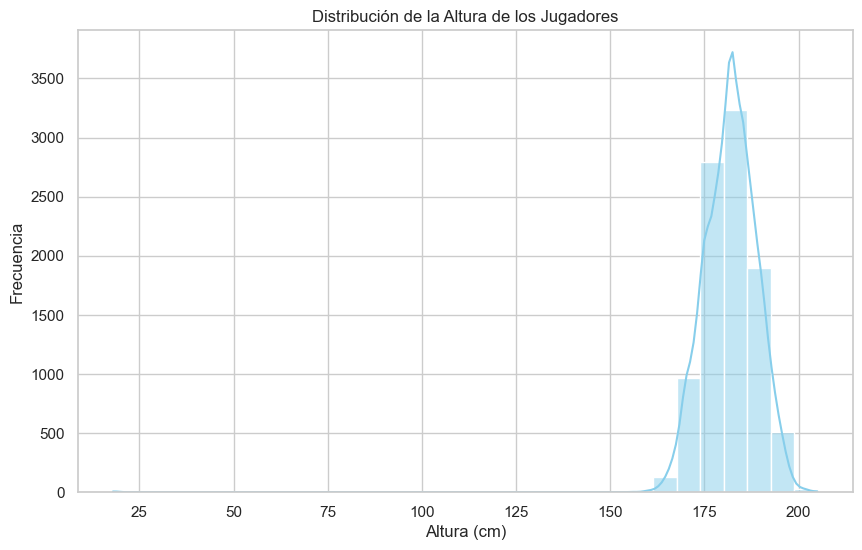

In [22]:
# Filtrar alturas mayores a cero para que el gráfico refleje la distribución real
df_alturas = df[df['height_in_cm'] > 0]

sns.histplot(data=df_alturas, x='height_in_cm', kde=True, bins=30, color='skyblue')
plt.title('Distribución de la Altura de los Jugadores')
plt.xlabel('Altura (cm)')
plt.ylabel('Frecuencia')
plt.show()

Objetivo:

* Detectar la distribución de las alturas.
* Observar posibles outliers.

### Valor de mercado

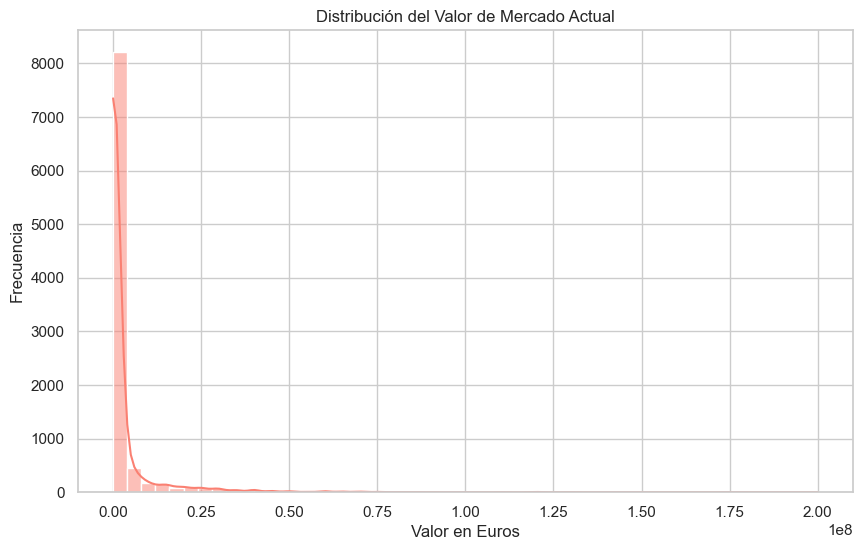

In [23]:
sns.histplot(data=df, x='market_value_in_eur', kde=True, bins=50, color='salmon')
plt.title('Distribución del Valor de Mercado Actual')
plt.xlabel('Valor en Euros')
plt.ylabel('Frecuencia')
plt.show()

Debido a la elevada asimetría:

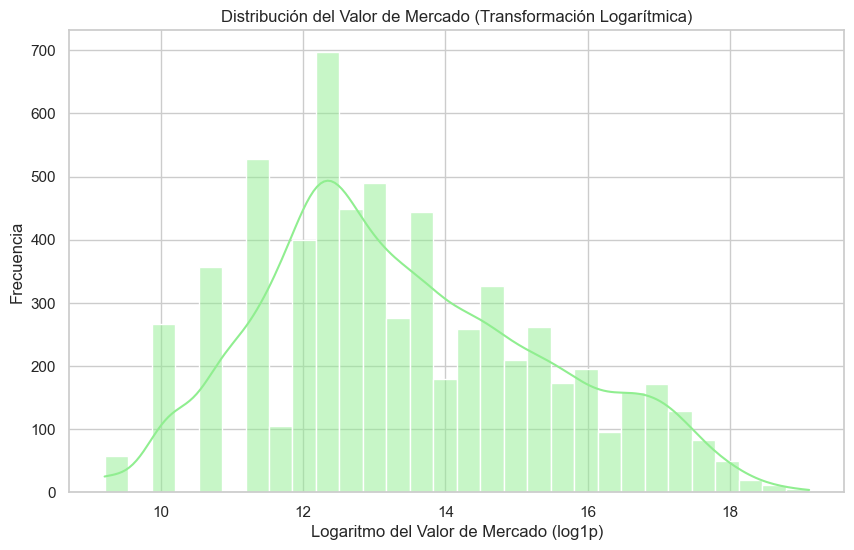

In [24]:
# Filtramos los jugadores con valor mayor a 0 para que los datos ausentes no distorsionen el logaritmo
df_valores = df[df['market_value_in_eur'] > 0]

# Graficamos aplicando la transformación logarítmica
sns.histplot(np.log1p(df_valores['market_value_in_eur']), kde=True, bins=30, color='lightgreen')

# Añadimos títulos y etiquetas claras
plt.title('Distribución del Valor de Mercado (Transformación Logarítmica)')
plt.xlabel('Logaritmo del Valor de Mercado (log1p)')
plt.ylabel('Frecuencia')
plt.show()

Interpretación:

* La mayoría de jugadores tienen valores bajos.
* Un reducido número concentra valores extremadamente elevados.

## 6. Análisis de variables categóricas

### Posición del jugador

In [25]:
df['position'].value_counts()

position
Defender      3080
Midfield      2787
Attack        2554
Goalkeeper    1108
Missing         32
Name: count, dtype: int64

Representación

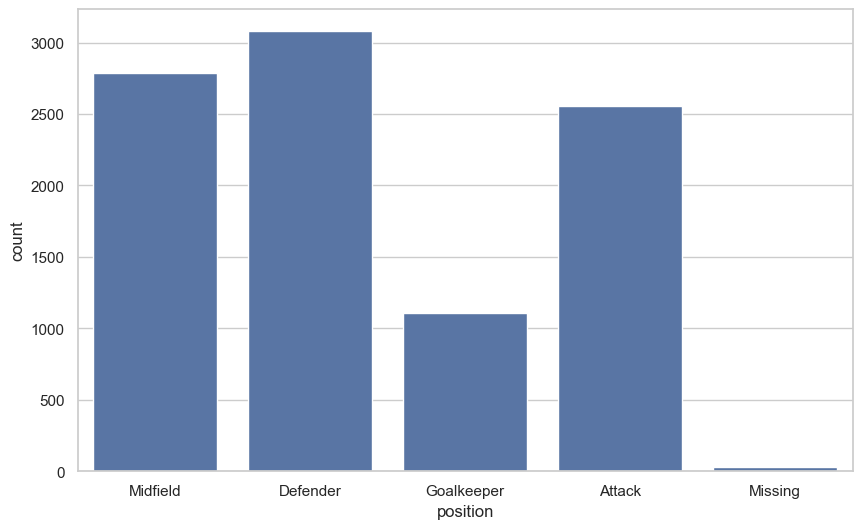

In [26]:
sns.countplot(data=df, x='position')
plt.show()

Permite conocer:

* Defensas.
* Centrocampistas.
* Delanteros.
* Porteros.

## 7. Detección de valores extremos

Para la altura:

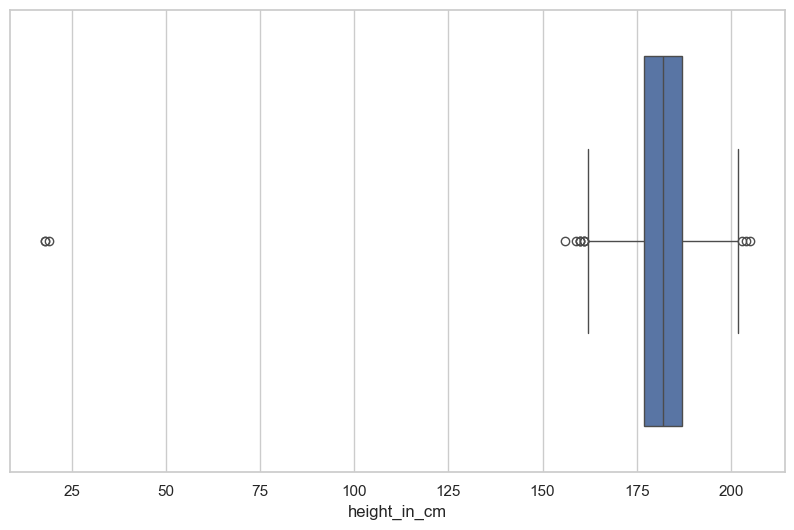

In [27]:
sns.boxplot(x=df['height_in_cm'])
plt.show()

Para el valor de mercado:

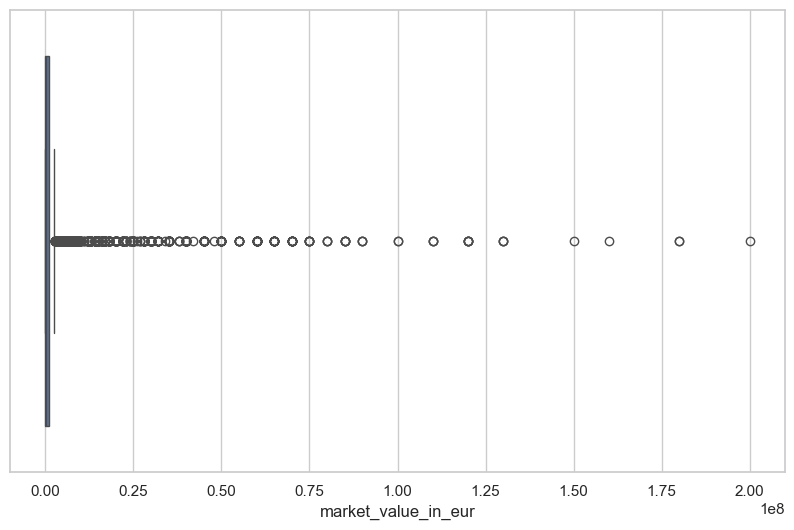

In [28]:
sns.boxplot(x=df['market_value_in_eur'])
plt.show()

Objetivo:

* Identificar observaciones alejadas del comportamiento general.

## 8. Relación entre variables

### Altura según posición

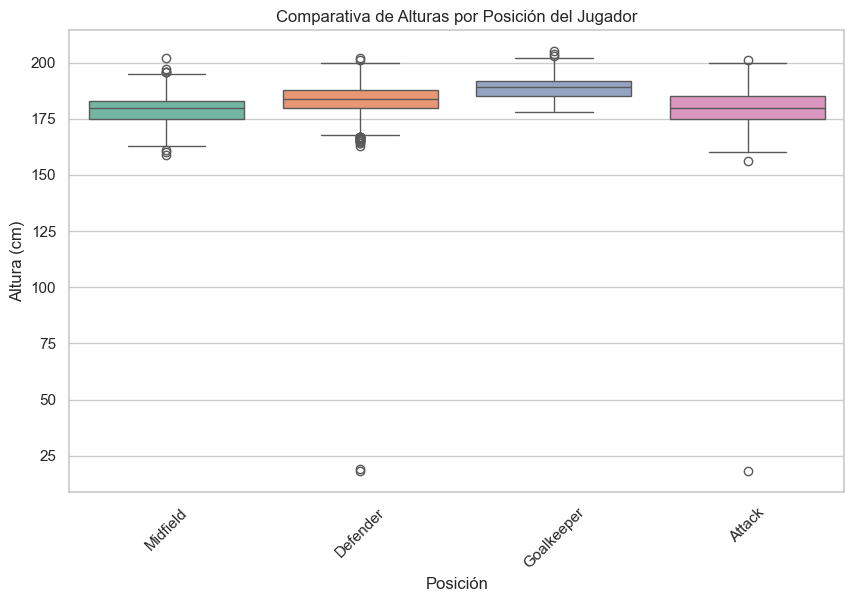

In [29]:
# 1. Filtramos los datos ignorando alturas vacías (0) y posiciones sin registrar
df_pos_alturas = df[(df['height_in_cm'] > 0) & (df['position'] != 'Missing')]

# 2. Creamos el boxplot corrigiendo la sintaxis de palette y hue
sns.boxplot(
    data=df_pos_alturas, 
    x='position', 
    y='height_in_cm', 
    hue='position',     # Asignamos hue a la misma variable X para dar color por grupo
    palette='Set2', 
    legend=False        # Desactivamos la leyenda automática ya que el eje X ya indica la posición
)

# 3. Formato y etiquetas del gráfico
plt.title('Comparativa de Alturas por Posición del Jugador')
plt.xlabel('Posición')
plt.ylabel('Altura (cm)')
plt.xticks(rotation=45)
plt.show()

Permite comprobar:

* Porteros y defensas suelen ser más altos.
* Delanteros y centrocampistas presentan alturas más variadas.

### Valor actual vs valor máximo alcanzado

In [ ]:
sns.scatterplot(data=df,
                x='market_value_in_eur',
                y='market_value_in_eur')
plt.show()

ValueError: Could not interpret value `highest_market_value_in_eur` for `y`. An entry with this name does not appear in `data`.

## 9. Matriz de correlación

Seleccionando las variables numéricas:

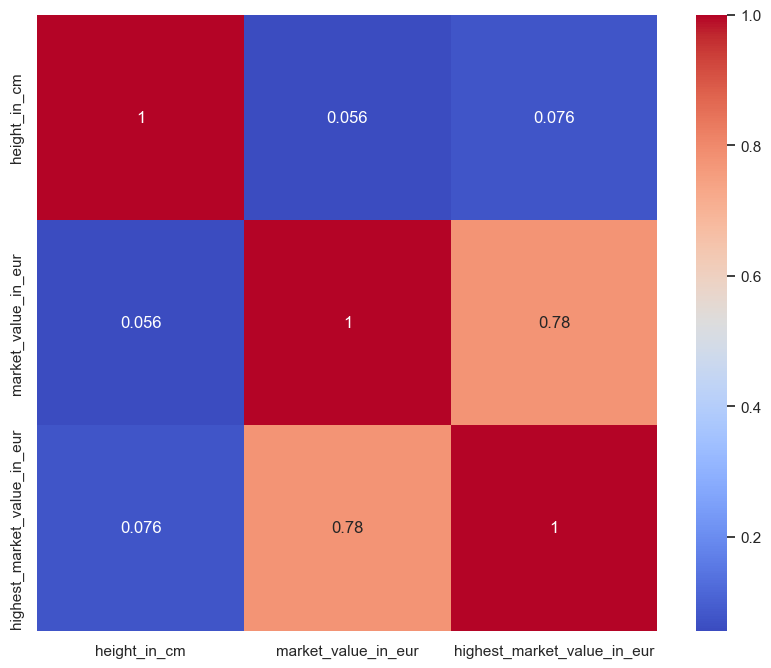

In [ ]:
corr = numericas.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

Permite analizar:

* Relaciones lineales entre variables.
* Variables altamente correlacionadas.

## 10. Jugadores con mayor valor de mercado

In [ ]:
df[['name','market_value_in_eur']]\
.sort_values(by='market_value_in_eur',
            ascending=False)\
.head(10)

,name,market_value_in_eur
24502,Erling Haaland,200000000
20806,Kylian Mbappé,180000000
22365,Vinicius Junior,180000000
30532,Jude Bellingham,160000000
24077,Phil Foden,150000000
30472,Jamal Musiala,130000000
29926,Michael Olise,130000000
25123,Bukayo Saka,130000000
22196,Federico Valverde,120000000
21254,Alexander Isak,120000000


Esto permite identificar los futbolistas más valiosos del conjunto.

## 11. Conclusiones del EDA

**Estructura del dataset**:

* El conjunto contiene 47.701 jugadores y 13 variables.

* Existe una combinación de variables numéricas y categóricas.

**Calidad de los datos:**

* El conjunto de datos ya se encuentra limpio y estructurado con 47.701 registros y 13 columnas esenciales.

* Los valores ausentes previos han sido estandarizados (los nulos en variables de texto y fechas aparecen controlados como `'0'` o `'Missing'`), evitando fallos en la ejecución del análisis.

**Distribuciones**:

* El valor de mercado presenta una fuerte asimetría.

* La altura muestra una distribución aproximadamente normal.

**Relaciones relevantes:**

* Como era de esperar, existe una correlación lineal positiva muy clara entre el valor actual de un jugador y su valor máximo histórico.

* Al analizar las alturas por posición, se confirma visualmente que los porteros (`Goalkeeper`) y los defensores (`Defender`) tienden a registrar los promedios de altura más altos del dataset.